In [13]:
# make top level dir available
import sys
sys.path.append("../../")

import numpy as np
import functions as myfunc
import meshtools as mt
import matplotlib.pyplot as plt

## Create Custom Figure, Make a Mesh from it

In [14]:
# custom values
EDGE_LENGTH = 1e-2 
EDGE_OFFSET = 1e-3 

# given paramters
RA = 0.3
DD = 0.01
HM = 0.08
BM = 0.08
MA = 0.01
MB = 0.05
RM0 = 0.095
ZM0 = 0.1
LLS = 0.001
SD = 0.005
SH = 0.01

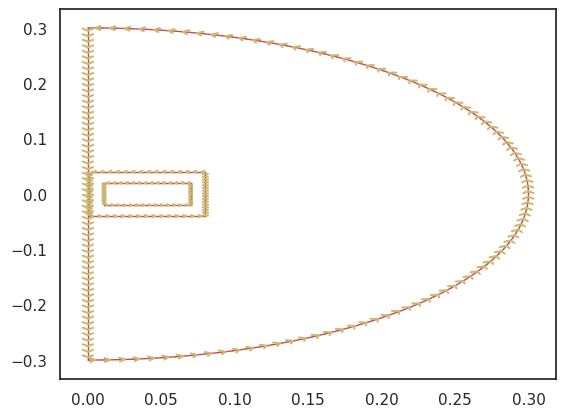

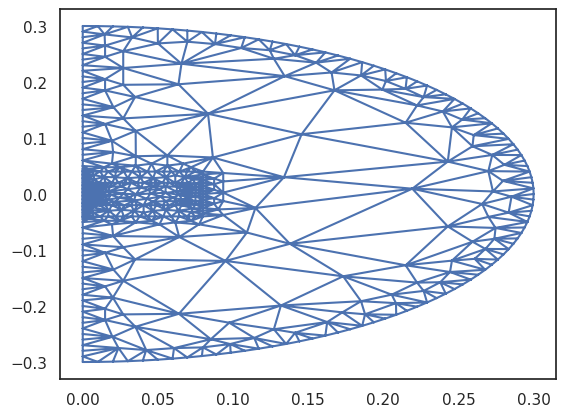

In [15]:
# Randkurve
knots, elements = mt.CircleSegments([0,0], radius=RA, a_min=-np.pi/2, a_max=np.pi/2, edge_length=EDGE_LENGTH)
knots2, elements2 = mt.LineSegments([0, RA], [0, -RA], edge_length=EDGE_LENGTH)
knots, elements = mt.AddSegments(knots, knots2, closed=True)

# Material
knots1, elements1 = mt.RectangleSegments([EDGE_OFFSET, -HM/2], [BM, HM/2], edge_length=EDGE_LENGTH/2)   # outer border
knots, elements = mt.AddCurves(knots, elements, knots1, elements1)

knots5, elements5 = mt.RectangleSegments([EDGE_OFFSET+DD, 2*DD-HM/2], [BM-DD, HM/2-2*DD])  # inner border
knots, elements = mt.AddCurves(knots, elements, knots5, elements5)
 
# # R Achse
# knots3, elements3 = mt.LineSegments([EDGE_OFFSET, EDGE_OFFSET], [RA, EDGE_OFFSET], edge_length=EDGE_LENGTH/2)
# knots, elements = mt.AddCurves(knots, elements, knots3, elements3)

# Smaller Mesh inside the material
def refine_mesh(triangle, area):
    """
    triangle are the x,y coordiantes of a singel triangle. Each row is a node.
    Area is the are of the triangle.

    The current triangle will be shrinked if the return value is true
    """
    centroid = myfunc._get_centroid(triangle)

    # check if triangle is inside the material
    # !: the new max area values have to be small enough to have an impact.
    if ( centroid[0] < BM ) and ( -HM/2 < centroid[1] < HM/2 ) :
        max_area = EDGE_LENGTH / 200
    else:
        max_area = EDGE_LENGTH / 2
    return bool(area > max_area)

    
mt.PlotBoundary(knots, elements, "Segments")
plt.show()
knots,triangles,BouE,li_BE,bou_elem,CuE,li_CE = mt.DoTriMesh(knots, elements, tri_refine=refine_mesh, edge_length=EDGE_LENGTH, writeTo="mesh")

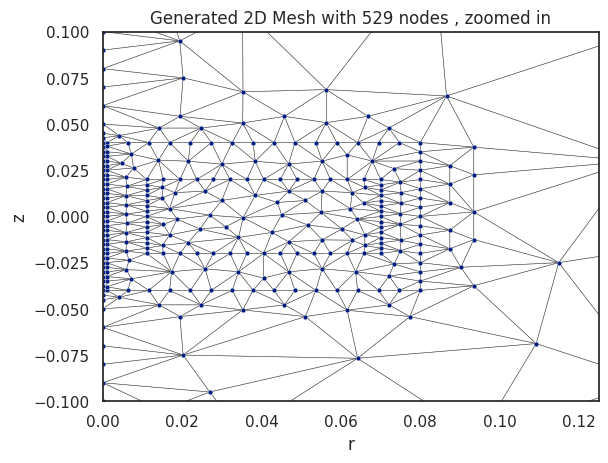

In [16]:
fig, ax = plt.subplots()
ax.set_xlim(0, 0.125)
ax.set_ylim(-0.1, 0.1)
myfunc.plot_knots_elements(knots, triangles, ax=ax, x_label="r", y_label="z", title_suffix=", zoomed in")

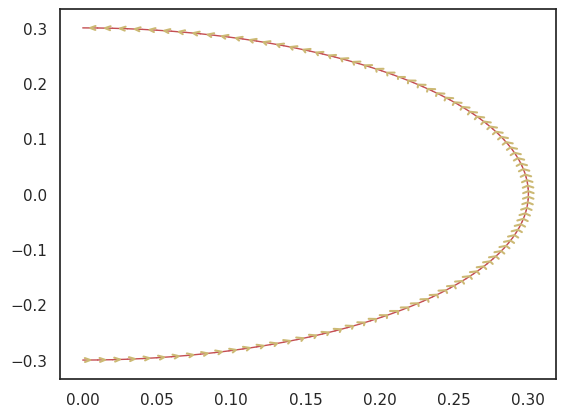

In [17]:
# Randkurven
Ps=[[0,RA],[0,-RA],[0,RA]]
bseg=mt.RetrieveSegments(knots,BouE,li_BE,Ps,['Nodes','Segments'])
mt.PlotBoundary(knots,bseg[0],'Nodes')
mt.PlotBoundary(knots,bseg[1],'Segments')
plt.show()